In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.tsa.stattools as adfuller
from statsmodels.tsa.stattools import adfuller
import warnings

warnings.filterwarnings("ignore")

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

sns.set_theme()

sns.set_theme(style="darkgrid")

In [2]:
df=pd.read_csv('Emission.csv')
df.head(1)

,Year-Month,CO2 Emission
0,1973-Jan,106.363


In [3]:
df['Year-Month']=pd.to_datetime(df['Year-Month'],format="%Y-%b",errors='coerce')


In [4]:
df.isna().sum()

Year-Month      0
CO2 Emission    0
dtype: int64

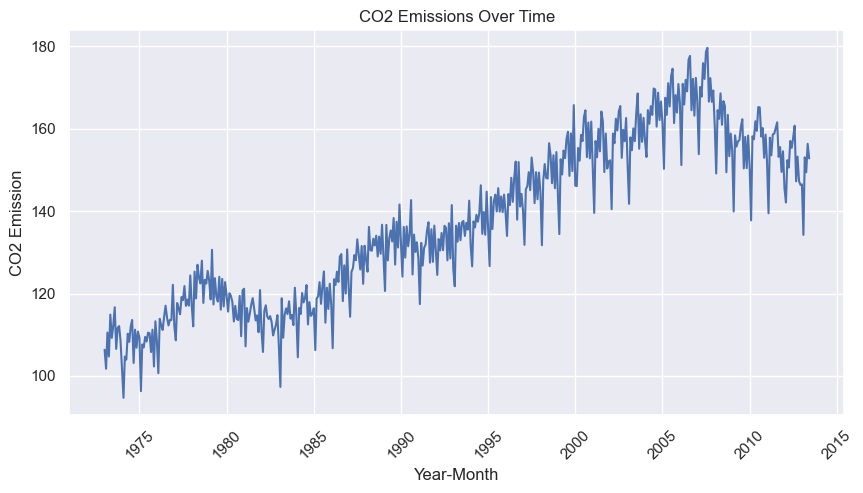

In [5]:
sns.set_theme(style="dark")

# Plot all years' time series in the same graph
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x="Year-Month", y="CO2 Emission", linestyle="-")

# Customize plot
plt.xlabel("Year-Month")
plt.ylabel("CO2 Emission")
plt.title("CO2 Emissions Over Time")
plt.xticks(rotation=45)
plt.grid(True)


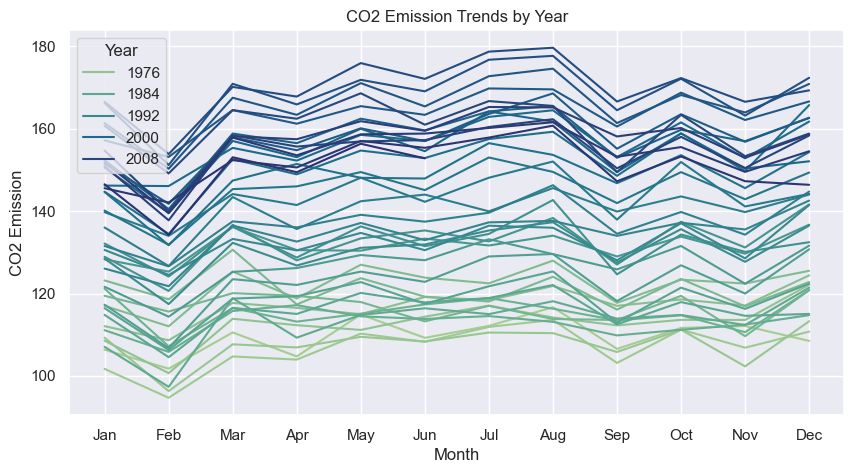

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample Data

# Convert "Year-Month" to datetime format
df["Year-Month"] = pd.to_datetime(df["Year-Month"], format="%Y-%b")

# Extract Year and Month
df["Year"] = df["Year-Month"].dt.year
df["Month"] = df["Year-Month"].dt.strftime("%b")  # Short month names

# Set Seaborn theme
sns.set_theme(style="dark")

# Plot all years in the same graph
plt.figure(figsize=(10, 5))

# Plot each year separately but aligned by month
sns.lineplot(data=df, x="Month", y="CO2 Emission", hue="Year", linestyle="-", palette="crest")

# Customize plot
plt.xlabel("Month")
plt.ylabel("CO2 Emission")
plt.title("CO2 Emission Trends by Year")
plt.legend(title="Year")
plt.grid(True)

# Show plot
plt.show()


As we can see from this graph there is some seasonality, and from these graph using the profile methode we can see that the model used here is additive model

<Axes: ylabel='CO2 Emission'>

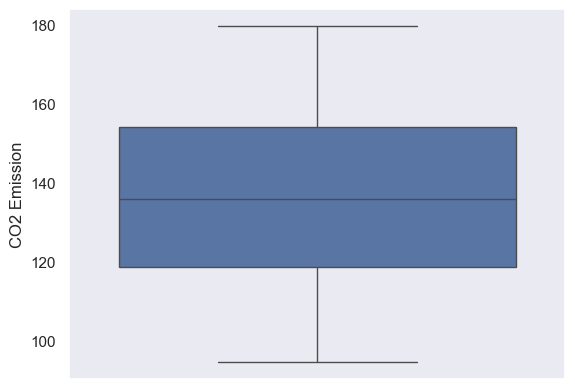

In [7]:
sns.boxplot(data=df,y='CO2 Emission')

from the box plot we can see that there is no outliers and the average of the CO2 Emission is around 135

<Axes: xlabel='CO2 Emission', ylabel='Count'>

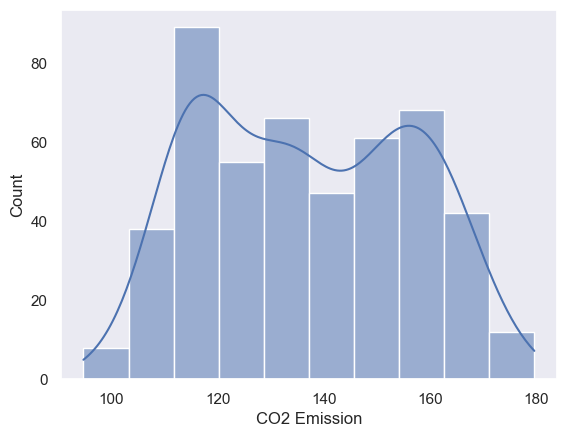

In [8]:
sns.histplot(data=df,x='CO2 Emission',kde=True)

In [9]:
from statsmodels.graphics.tsaplots import plot_acf

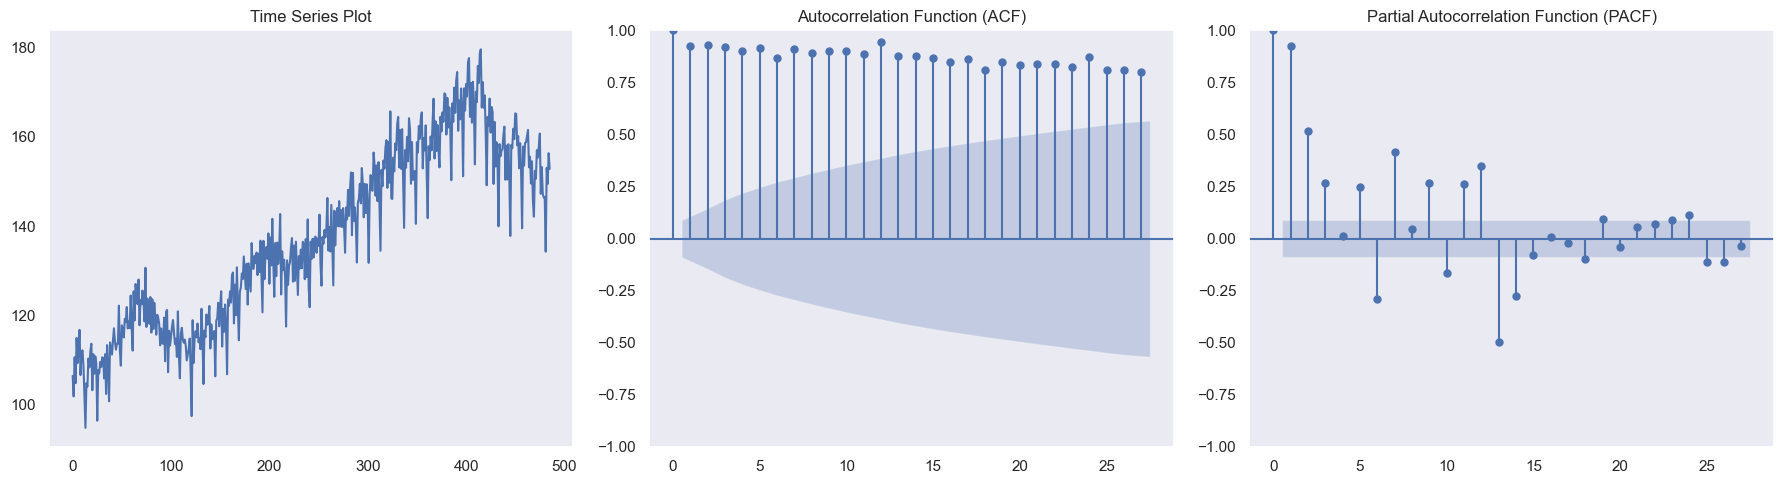

In [10]:

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(df["CO2 Emission"])
plt.title("Time Series Plot")

plt.subplot(1, 3, 2)
plot_acf(df["CO2 Emission"], ax=plt.gca())  
plt.title("Autocorrelation Function (ACF)")

plt.subplot(1, 3, 3)
plot_pacf(df["CO2 Emission"], ax=plt.gca())  
plt.title("Partial Autocorrelation Function (PACF)")

plt.tight_layout()
plt.show()


Index of DataFrame: DatetimeIndex(['1973-01-01', '1973-02-01', '1973-03-01', '1973-04-01',
               '1973-05-01', '1973-06-01', '1973-07-01', '1973-08-01',
               '1973-09-01', '1973-10-01',
               ...
               '2012-09-01', '2012-10-01', '2012-11-01', '2012-12-01',
               '2013-01-01', '2013-02-01', '2013-03-01', '2013-04-01',
               '2013-05-01', '2013-06-01'],
              dtype='datetime64[ns]', name='Year-Month', length=486, freq=None)

ADF Test Result (Difference Order = 0):
ADF Statistic: -1.7231486969927146
p-value: 0.4192267624634094
Critical Values: {'1%': np.float64(-3.4444002781824477), '5%': np.float64(-2.867735576537528), '10%': np.float64(-2.57007000456571)}
Series is non-stationary. Applying differencing...

ADF Test Result (Difference Order = 1):
ADF Statistic: -3.8907729022324697
p-value: 0.002103812687451334
Critical Values: {'1%': np.float64(-3.4444305322234365), '5%': np.float64(-2.8677488864580885), '10%': np.float64(-2

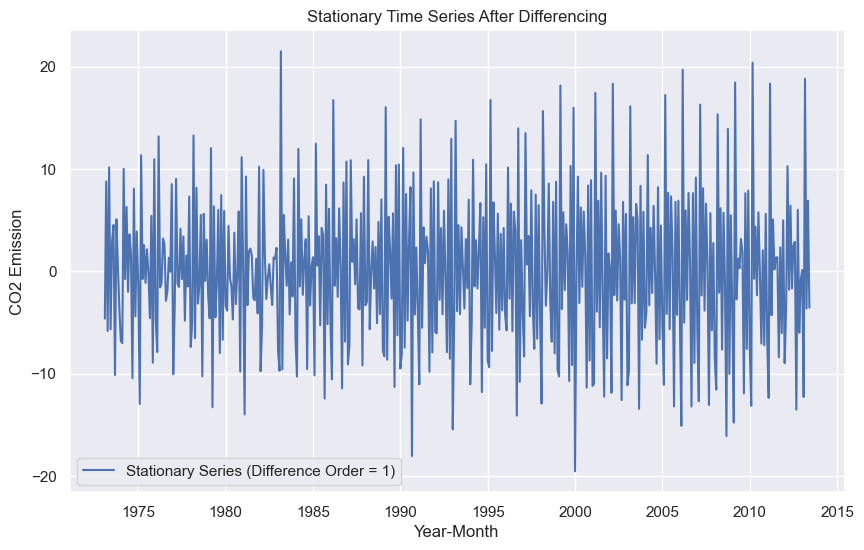

In [11]:
if 'Year-Month' in df.columns:
    df.set_index('Year-Month', inplace=True)
else:
    print("'Year-Month' is already the index.")

# Check the index
print("Index of DataFrame:", df.index)

# Function to perform ADF test and differencing
def make_stationary(series, max_diff=10):
    diff_count = 0
    while diff_count < max_diff:
        # Perform ADF test
        adf_result = adfuller(series.dropna())
        p_value = adf_result[1]
        
        # Print ADF results
        print(f"\nADF Test Result (Difference Order = {diff_count}):")
        print(f"ADF Statistic: {adf_result[0]}")
        print(f"p-value: {p_value}")
        print(f"Critical Values: {adf_result[4]}")
        
        # Check if stationary
        if p_value < 0.05:
            print(f"Series is stationary after {diff_count} differencing step(s).")
            return series, diff_count
        else:
            print("Series is non-stationary. Applying differencing...")
            series = series.diff().dropna()  # Apply first-order differencing
            diff_count += 1
    
    print(f"Series could not be made stationary after {max_diff} differencing steps.")
    return series, diff_count

# Apply the function to make the series stationary
stationary_series, diff_order = make_stationary(df['CO2 Emission'])

# Plot the stationary series
plt.figure(figsize=(10, 6))
plt.plot(stationary_series, label=f'Stationary Series (Difference Order = {diff_order})')
plt.title('Stationary Time Series After Differencing')
plt.xlabel('Year-Month')
plt.ylabel('CO2 Emission')
plt.legend()
plt.grid()
plt.show()

Our time series isn't stationary so we should use ARIMA not ARMA 

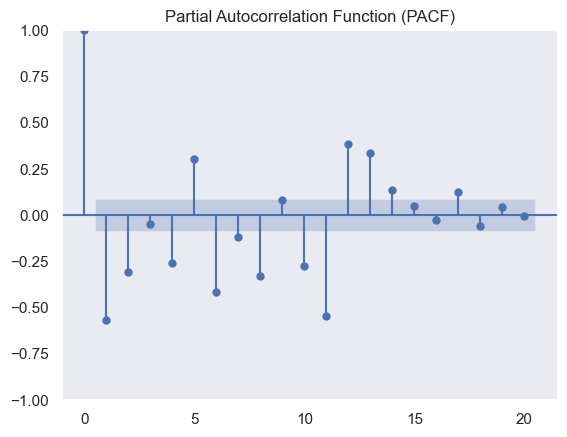

In [12]:
from statsmodels.graphics.tsaplots import plot_pacf


plot_pacf(stationary_series, lags=20)
plt.title('Partial Autocorrelation Function (PACF)')
plt.show()

as we can see the PACF drop in like 15 so we take 15 as our 'p' AR(p) which the number of past values we take 

                               SARIMAX Results                                
Dep. Variable:           CO2 Emission   No. Observations:                  388
Model:                 ARIMA(6, 0, 7)   Log Likelihood               -1033.177
Date:                Wed, 02 Apr 2025   AIC                           2096.354
Time:                        16:45:34   BIC                           2155.769
Sample:                    02-01-1973   HQIC                          2119.911
                         - 05-01-2005                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1394      0.037      3.753      0.000       0.067       0.212
ar.L1         -0.0327      0.019     -1.728      0.084      -0.070       0.004
ar.L2         -0.0238      0.019     -1.254      0.2

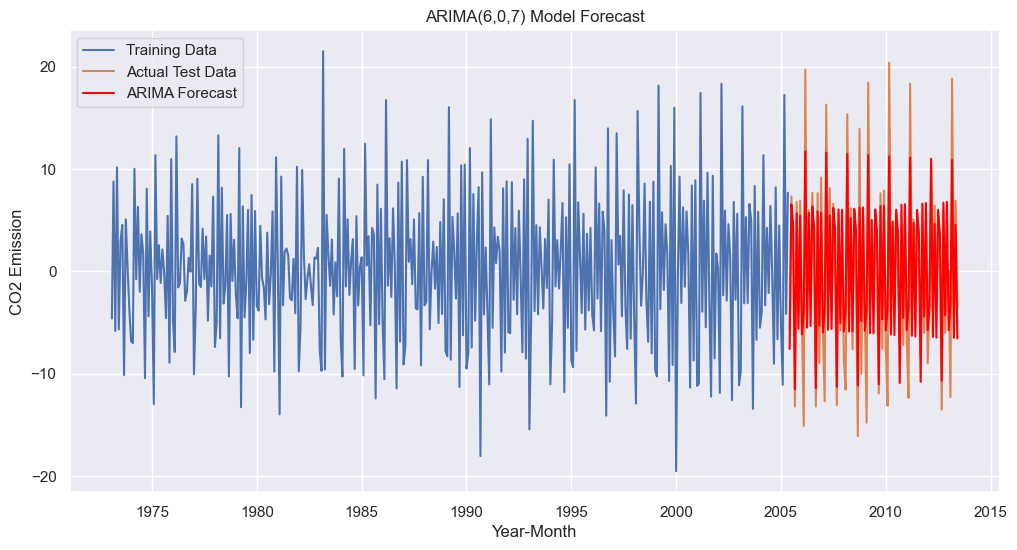

In [13]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

train_size = int(len(df) * 0.8)
train, test = stationary_series.iloc[:train_size], stationary_series.iloc[train_size:]

# Define ARIMA model with p=15, d=1, q=4
p, d, q = 6,0,7 # AR=15, Differencing=1, MA=4
model = ARIMA(train, order=(p, d, q))

# Fit the model
fitted_model = model.fit()

# Print model summary
print(fitted_model.summary())

# Forecast on the test set
forecast = fitted_model.forecast(steps=len(test))

# Evaluate the model
mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test, forecast)
r2 = r2_score(test, forecast)

print(f"\nEvaluation Metrics:")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R²: {r2}")

# Plot actual vs predicted values
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual Test Data')
plt.plot(test.index, forecast, label='ARIMA Forecast', color='red')
plt.title(f'ARIMA({p},{d},{q}) Model Forecast')
plt.xlabel('Year-Month')
plt.ylabel('CO2 Emission')
plt.legend()
plt.grid()
plt.show()

In [14]:
import itertools
import statsmodels.api as sm

# Define search space for p and q
p = q = range(0, 8)  # p and q range from 0 to 4
d = 1  # Fixed differencing order (d = 1)

best_aic = float('inf')
best_order = None

# Try all (p, d=1, q) combinations
for order in itertools.product(p, [d], q):  # Fix d=1 and iterate over p and q
    try:
        model = sm.tsa.ARIMA(df['CO2 Emission'], order=order).fit()
        if model.aic < best_aic:
            best_aic = model.aic
            best_order = order
    except Exception as e:
        # Optionally log the error or problematic order
        print(f"Failed to fit ARIMA{order}: {e}")
        continue

if best_order is not None:
    print(f"Best ARIMA Order: {best_order} with AIC={best_aic}")
else:
    print("No suitable ARIMA model found.")

Best ARIMA Order: (6, 1, 7) with AIC=2622.6420480279758


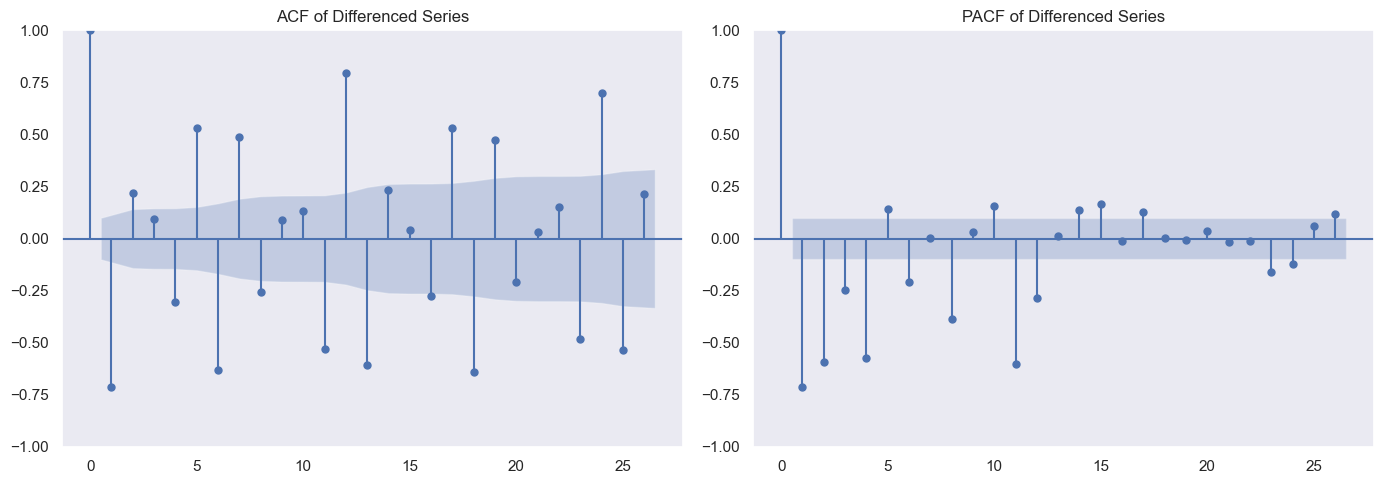

In [15]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Differencing the time series (since d=1 in ARIMA(6,1,7))
diff_series = train.diff(1).dropna()

plt.figure(figsize=(14, 5))


plt.subplot(1, 2, 1)
plot_acf(diff_series, ax=plt.gca())  
plt.title("ACF of Differenced Series")

plt.subplot(1, 2, 2)
plot_pacf(diff_series, ax=plt.gca())  
plt.title("PACF of Differenced Series")

plt.tight_layout()
plt.show()


In [16]:
n=len(df)
train_size=int(n*0.8)
train=df['CO2 Emission'].iloc[:train_size]
test=df['CO2 Emission'].iloc[train_size:]

In [17]:
from statsmodels.tsa.arima.model import ARIMA


In [18]:
model = ARIMA(train, order=(6, 1, 7))
result=model.fit()

In [19]:
step=30

fc = result.forecast(step)



In [20]:
fc=pd.DataFrame(fc)
fc.index=test[:30].index

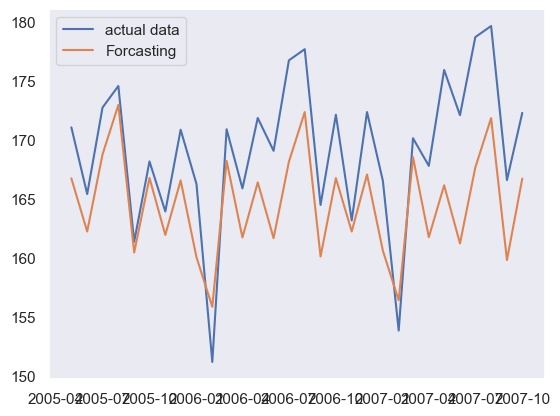

In [21]:
plt.plot(test[:30],label='actual data')
plt.plot(fc,label='Forcasting')
plt.legend()
plt.show()


As we can see from the Focasting graph that the ARIMA model sturggles with non linear trends which make it unsuitable for our data which have non linear trend  since it's linear model it can't capture complex relation

In [22]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(test[:30], fc)
rmse = np.sqrt(mse)  # Root Mean Squared Error
mae = mean_absolute_error(test[:30], fc)
r2 = r2_score(test[:30], fc)  # R-squared


print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

MSE: 32.4980
RMSE: 5.7007
MAE: 5.0039
R²: 0.2057


In [23]:
print("AIC:", result.aic)
print("BIC:", result.bic)


AIC: 2090.5083726764237
BIC: 2145.9263183788407


# SARIMA

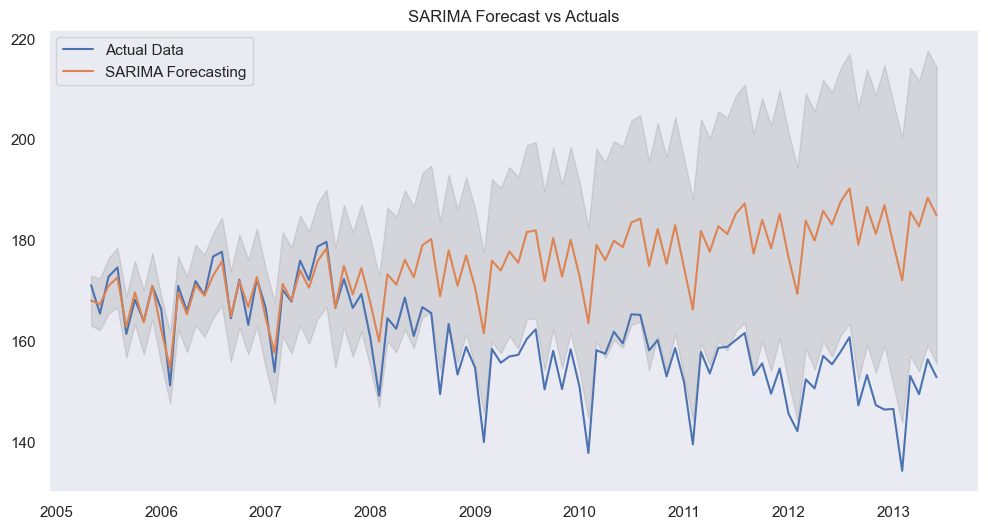

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Assuming your data is monthly and has yearly seasonality (seasonal period = 12)
# Modify the seasonal_order parameter according to your data frequency if different

# SARIMA parameters:
# order=(p,d,q) - non-seasonal parameters (same as ARIMA)
# seasonal_order=(P,D,Q,s) - seasonal parameters where s is the seasonal period
# For yearly seasonality in monthly data, s=12

model = SARIMAX(train, 
                order=(6, 1, 7),          # Non-seasonal order (p,d,q)
                seasonal_order=(1, 1, 1, 12),  # Seasonal order (P,D,Q,s)
                enforce_stationarity=False,
                enforce_invertibility=False)

result = model.fit()

step = 98
fc = result.get_forecast(steps=step)
fc_mean = fc.predicted_mean
fc_conf = fc.conf_int()

# Convert to DataFrame for plotting
fc_df = pd.DataFrame(fc_mean)
fc_df.index = test[:step].index

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(test[:step], label='Actual Data')
plt.plot(fc_df, label='SARIMA Forecasting')
plt.fill_between(fc_conf.index,
                fc_conf.iloc[:, 0],
                fc_conf.iloc[:, 1], color='k', alpha=0.1)
plt.title('SARIMA Forecast vs Actuals')
plt.legend()
plt.show()


In [29]:

# Calculate metrics
mse = mean_squared_error(test[:step], fc_mean)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test[:step], fc_mean)
r2 = r2_score(test[:step], fc_mean)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")


MSE: 325.3612
RMSE: 18.0378
MAE: 14.4854
R²: -3.0076


In [30]:
test.shape

(98,)